In [5]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
import gc

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [6]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [7]:
%cd /content/drive/MyDrive/CursoPINN-CEIA-UBA/20253B/Material didáctico/Modulo7

/content/drive/MyDrive/CursoPINN-CEIA-UBA/20253B/Material didáctico/Modulo7


In [8]:
def activation(name):
    if name in ['tanh', 'Tanh']:
        return nn.Tanh()
    elif name in ['relu', 'ReLU']:
        return nn.ReLU(inplace=True)
    elif name in ['lrelu', 'LReLU']:
        return nn.LeakyReLU(inplace=True)
    elif name in ['sigmoid', 'Sigmoid']:
        return nn.Sigmoid()
    elif name in ['softplus', 'Softplus']:
        return nn.Softplus(beta=4)
    elif name in ['celu', 'CeLU']:
        return nn.CELU()
    elif name in ['elu']:
        return nn.ELU()
    elif name in ['mish']:
        return nn.Mish()
    else:
        raise ValueError('Unknown activation function')


In [9]:
class SpectralConv2d(nn.Module):
    """
    2D Fourier convolution layer.
    Performs FFT2 → multiply low-frequency modes by learned complex weights → inverse FFT2.
    """
    def __init__(self, in_channels, out_channels, num_modes_x, num_modes_y):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_modes_x = num_modes_x  # number of modes to keep along x
        self.num_modes_y = num_modes_y  # number of modes to keep along y

        # Learnable complex weights for low frequencies
        scale = 1 / (in_channels * out_channels)
        self.fourier_weights = nn.Parameter(
            scale * torch.rand(in_channels, out_channels,
                               num_modes_x, num_modes_y, dtype=torch.cfloat)
        )

    def complex_multiply(self, input_ft, weights):
        """
        input_ft: (batch, in_channel, kx, ky)
        weights:  (in_channel, out_channel, kx, ky)
        return:   (batch, out_channel, kx, ky)
        """
        return torch.einsum("bixy,ioxy->boxy", input_ft, weights)

    def forward(self, x):
        """
        x: (batch, in_channel, Nx, Ny)
        """
        batch_size, _, Nx, Ny = x.shape

        # FFT: real-to-complex 2D
        x_ft = torch.fft.rfft2(x, norm="forward")

        # Output Fourier tensor
        out_ft = torch.zeros(
            batch_size, self.out_channels, Nx, Ny // 2 + 1,
            device=x.device, dtype=torch.cfloat
        )

        # Apply learned weights to low-frequency modes
        out_ft[:, :, :self.num_modes_x, :self.num_modes_y] = self.complex_multiply(
            x_ft[:, :, :self.num_modes_x, :self.num_modes_y],
            self.fourier_weights
        )

        # Inverse FFT: back to real space
        x_out = torch.fft.irfft2(out_ft, s=(Nx, Ny), norm="forward")
        return x_out


In [10]:
class SpectralConv2dFFT(nn.Module):
    """
    2D Fourier convolution using full complex fft2/ifft2.
    Keeps four low-frequency blocks (±kx, ±ky).
    """
    def __init__(self, in_channels, out_channels, num_modes_x, num_modes_y):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_modes_x = num_modes_x
        self.num_modes_y = num_modes_y

        scale = 1.0 / (in_channels * out_channels)
        def cplx_randn(*shape):
            return torch.randn(*shape, dtype=torch.cfloat)

        # Four corners
        self.w_11 = nn.Parameter(scale * cplx_randn(in_channels, out_channels, num_modes_x, num_modes_y))  # (+kx,+ky)
        self.w_1n = nn.Parameter(scale * cplx_randn(in_channels, out_channels, num_modes_x, num_modes_y))  # (+kx,-ky)
        self.w_n1 = nn.Parameter(scale * cplx_randn(in_channels, out_channels, num_modes_x, num_modes_y))  # (-kx,+ky)
        self.w_nn = nn.Parameter(scale * cplx_randn(in_channels, out_channels, num_modes_x, num_modes_y))  # (-kx,-ky)

    @staticmethod
    def _cmul2d(inp_ft, w):
        return torch.einsum("bixy,ioxy->boxy", inp_ft, w)

    def forward(self, x):
        """
        x: [B, Cin, Nx, Ny] real
        """
        B, Cin, Nx, Ny = x.shape
        mx = min(self.num_modes_x, Nx//2)  # be conservative vs size
        my = min(self.num_modes_y, Ny//2)

        x_ft = torch.fft.fft2(x, dim=(-2, -1), norm="forward")               # [B, Cin, Nx, Ny]
        out_ft = torch.zeros(B, self.out_channels, Nx, Ny,
                             dtype=torch.cfloat, device=x.device)

        # (+kx, +ky)
        out_ft[:, :, :mx, :my] = self._cmul2d(x_ft[:, :, :mx, :my], self.w_11)
        # (+kx, -ky)
        out_ft[:, :, :mx, -my:] = self._cmul2d(x_ft[:, :, :mx, -my:], self.w_1n)
        # (-kx, +ky)
        out_ft[:, :, -mx:, :my] = self._cmul2d(x_ft[:, :, -mx:, :my], self.w_n1)
        # (-kx, -ky)
        out_ft[:, :, -mx:, -my:] = self._cmul2d(x_ft[:, :, -mx:, -my:], self.w_nn)

        x_out = torch.fft.ifft2(out_ft, dim=(-2, -1), norm="forward").real
        return x_out


In [11]:
class SpectralConv2dRFFT(nn.Module):
    """
    2D Fourier convolution layer using rFFT (last axis is half-spectrum).
    Keeps low modes in two 'corners' along kx: [:mx, :my] and [-mx:, :my].
    """
    def __init__(self, in_channels, out_channels, num_modes_x, num_modes_y):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_modes_x = num_modes_x  # kept modes along x
        self.num_modes_y = num_modes_y  # kept modes along y (non-negative only with rfft2)

        scale = 1.0 / (in_channels * out_channels)
        # init with symmetric distribution (better than rand on C)
        def cplx_randn(*shape):
            return torch.randn(*shape, dtype=torch.cfloat)

        # Two blocks: low kx at start; low (negative kx) at end
        self.weights_poskx = nn.Parameter(
            scale * cplx_randn(in_channels, out_channels, num_modes_x, num_modes_y)
        )
        self.weights_negkx = nn.Parameter(
            scale * cplx_randn(in_channels, out_channels, num_modes_x, num_modes_y)
        )

    @staticmethod
    def _cmul2d(inp_ft, w):
        # inp_ft: [B, Cin, kx, ky], w: [Cin, Cout, kx, ky] -> [B, Cout, kx, ky]
        return torch.einsum("bixy,ioxy->boxy", inp_ft, w)

    def forward(self, x):
        """
        x: [B, Cin, Nx, Ny] real
        returns: [B, Cout, Nx, Ny] real
        """
        B, Cin, Nx, Ny = x.shape
        mx = min(self.num_modes_x, Nx)
        my = min(self.num_modes_y, Ny//2 + 1)

        # rFFT2 over the last two dims
        x_ft = torch.fft.rfft2(x, dim=(-2, -1), norm="forward")              # [B, Cin, Nx, Ny//2+1]
        out_ft = torch.zeros(B, self.out_channels, Nx, Ny//2 + 1,
                             dtype=torch.cfloat, device=x.device)

        # Corner 1: kx low (0..mx-1), ky low (0..my-1)
        out_ft[:, :, :mx, :my] = self._cmul2d(x_ft[:, :, :mx, :my], self.weights_poskx)

        # Corner 2: kx 'negative' (wrap-around end), ky low
        out_ft[:, :, -mx:, :my] = self._cmul2d(x_ft[:, :, -mx:, :my], self.weights_negkx)

        # Back to real space
        x_out = torch.fft.irfft2(out_ft, s=(Nx, Ny), dim=(-2, -1), norm="forward")
        return x_out


In [12]:
class FNO2d(nn.Module):
    """
    2D Fourier Neural Operator.
    Structure:
    1. Lift input to higher channel dimension with a linear layer.
    2. Apply several Fourier layers (SpectralConv + pointwise Conv2d).
    3. Project back to output dimension.
    """
    def __init__(self, num_modes_x, num_modes_y, width, num_fourier_layers=4):
        super().__init__()
        self.width = width

        # Step 1: Input projection (3 → width)
        # Three input channels: u0(x,y), x, y
        self.input_proj = nn.Linear(3, width)

        # Step 2: Fourier layers
        self.fourier_layers = nn.ModuleList()
        self.pointwise_layers = nn.ModuleList()
        for _ in range(num_fourier_layers):
            self.fourier_layers.append(SpectralConv2dRFFT(width, width, num_modes_x, num_modes_y))
            self.pointwise_layers.append(nn.Conv2d(width, width, kernel_size=1))

        # Step 3: Output projection
        self.hidden_proj = nn.Linear(width, 64)
        self.output_proj = nn.Linear(64, 1)

        self.activation = nn.Tanh()

    def forward(self, x):
        """
        x: (batch, Nx, Ny, 3)  -- channels: (u0, x, y)
        returns: (batch, Nx, Ny, 1)
        """
        B, Nx, Ny, C = x.shape

        # Lift input
        x = self.input_proj(x)                           # (B, Nx, Ny, width)
        x = x.permute(0, 3, 1, 2)                        # (B, width, Nx, Ny)

        # Apply Fourier + pointwise layers
        for spectral_layer, pointwise_layer in zip(self.fourier_layers, self.pointwise_layers):
            x = spectral_layer(x) + pointwise_layer(x)   # global + local term
            x = self.activation(x)

        # Project back
        x = x.permute(0, 2, 3, 1)                        # (B, Nx, Ny, width)
        x = self.activation(self.hidden_proj(x))
        x = self.output_proj(x)                          # (B, Nx, Ny, 1)
        return x


In [13]:
# Load the data
x_data = torch.from_numpy(np.load("AC_data_input.npy")).type(torch.float32)
y_data = torch.from_numpy(np.load("AC_data_output.npy")).type(torch.float32)

print(f'x_data shape: {x_data.shape}')
print(f'y_data shape: {y_data.shape}')

x_data shape: torch.Size([1000, 1001, 2])
y_data shape: torch.Size([1000, 1001])


In [14]:
x_data[:, :, 0]

tensor([[-1.0000, -0.9980, -0.9960,  ...,  0.9960,  0.9980,  1.0000],
        [-1.0000, -0.9980, -0.9960,  ...,  0.9960,  0.9980,  1.0000],
        [-1.0000, -0.9980, -0.9960,  ...,  0.9960,  0.9980,  1.0000],
        ...,
        [-1.0000, -0.9980, -0.9960,  ...,  0.9960,  0.9980,  1.0000],
        [-1.0000, -0.9980, -0.9960,  ...,  0.9960,  0.9980,  1.0000],
        [-1.0000, -0.9980, -0.9960,  ...,  0.9960,  0.9980,  1.0000]])

In [15]:
x_data[:, :, 1]

tensor([[ 0.0000,  0.0182,  0.0365,  ..., -0.0365, -0.0182,  0.0000],
        [ 0.0000,  0.0615,  0.1229,  ..., -0.1229, -0.0615,  0.0000],
        [ 0.0000,  0.0913,  0.1826,  ..., -0.1826, -0.0913,  0.0000],
        ...,
        [ 0.0000,  0.0251,  0.0502,  ..., -0.0502, -0.0251,  0.0000],
        [ 0.0000, -0.0342, -0.0683,  ...,  0.0683,  0.0342,  0.0000],
        [ 0.0000, -0.0374, -0.0748,  ...,  0.0748,  0.0374,  0.0000]])

In [16]:
n_samples = x_data.shape[0]

xi, xf = x_data[0, :, 0].min(), x_data[0, :, 0].max()
ti, tf = 0., 1.
L = xf - xi

nx, nt = 200, 100
x = torch.linspace(xi, xf, nx)      # spatial domain
t = torch.linspace(ti, tf, nt)      # temporal domain

X, T = torch.meshgrid(x, t, indexing="ij")   # shape (nx, nt)
input_data = torch.zeros((x_data.shape[0], nx, nt, 3)) # 3 input channels
output_data = torch.zeros((x_data.shape[0], nx))

print(f'input_data shape: {input_data.shape}')
print(f'output_data shape: {output_data.shape}')

input_data shape: torch.Size([1000, 200, 100, 3])
output_data shape: torch.Size([1000, 200])


In [17]:
for i in range(n_samples):
    # initial condition u(x,0) from data
    u0_i = x_data[i, :, 1]   # shape (1001,)

    # interpolate to nx grid (from 1001 to nx)
    u0_interp_i = torch.from_numpy(np.interp(x, x_data[i, :, 0], u0_i)).to(torch.float32)  # (nx,)

    # broadcast IC along time
    U0 = u0_interp_i[:, None].repeat(1, nt)  # shape (nx, nt)

    # assign channels
    input_data[i, :, :, 0] = U0  # IC
    input_data[i, :, :, 1] = X   # spatial coord
    input_data[i, :, :, 2] = T   # temporal coord

    u1_interp = torch.from_numpy(np.interp(x, x_data[i, :, 0], y_data[i, :])).to(torch.float32)  # (nx,)
    output_data[i, :] = u1_interp

In [18]:
input_data[0, :, :, 0]

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0916,  0.0916,  0.0916,  ...,  0.0916,  0.0916,  0.0916],
        [ 0.1826,  0.1826,  0.1826,  ...,  0.1826,  0.1826,  0.1826],
        ...,
        [-0.1826, -0.1826, -0.1826,  ..., -0.1826, -0.1826, -0.1826],
        [-0.0916, -0.0916, -0.0916,  ..., -0.0916, -0.0916, -0.0916],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])

In [19]:
input_data[0, :, :, 1]

tensor([[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
        [-0.9899, -0.9899, -0.9899,  ..., -0.9899, -0.9899, -0.9899],
        [-0.9799, -0.9799, -0.9799,  ..., -0.9799, -0.9799, -0.9799],
        ...,
        [ 0.9799,  0.9799,  0.9799,  ...,  0.9799,  0.9799,  0.9799],
        [ 0.9899,  0.9899,  0.9899,  ...,  0.9899,  0.9899,  0.9899],
        [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000]])

In [20]:
input_data[0, :, :, 2]

tensor([[0.0000, 0.0101, 0.0202,  ..., 0.9798, 0.9899, 1.0000],
        [0.0000, 0.0101, 0.0202,  ..., 0.9798, 0.9899, 1.0000],
        [0.0000, 0.0101, 0.0202,  ..., 0.9798, 0.9899, 1.0000],
        ...,
        [0.0000, 0.0101, 0.0202,  ..., 0.9798, 0.9899, 1.0000],
        [0.0000, 0.0101, 0.0202,  ..., 0.9798, 0.9899, 1.0000],
        [0.0000, 0.0101, 0.0202,  ..., 0.9798, 0.9899, 1.0000]])

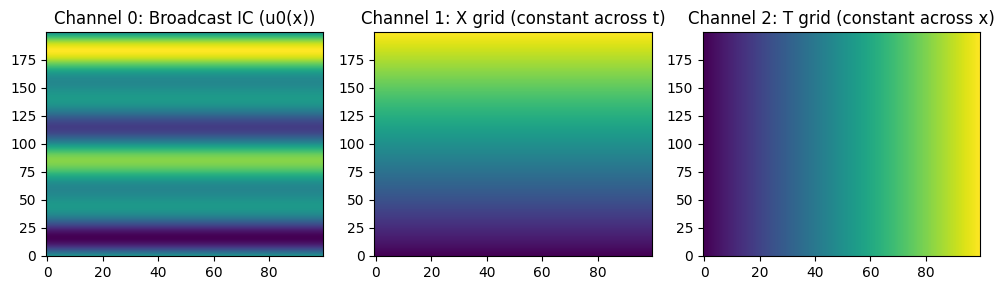

In [21]:
# Sanity check
i = 7
U0_broadcast = input_data[i, :, :, 0]  # IC channel
X_channel    = input_data[i, :, :, 1]  # x channel
T_channel    = input_data[i, :, :, 2]  # t channel

# === Sanity checks ===
fig, axs = plt.subplots(1, 3, figsize=(10, 3))

# 1. Initial condition broadcast along t
axs[0].imshow(U0_broadcast.numpy(), aspect="auto", origin="lower")
axs[0].set_title("Channel 0: Broadcast IC (u0(x))")

# 2. Spatial channel
axs[1].imshow(X_channel.numpy(), aspect="auto", origin="lower")
axs[1].set_title("Channel 1: X grid (constant across t)")

# 3. Temporal channel
axs[2].imshow(T_channel.numpy(), aspect="auto", origin="lower")
axs[2].set_title("Channel 2: T grid (constant across x)")

plt.tight_layout()
plt.show()


In [22]:
n_train = 100 # number of training samples
input_data_train = input_data[:n_train, ...]
output_data_train = output_data[:n_train, :]

input_data_test = input_data[n_train:, :]
output_data_test = output_data[n_train:, :]

In [23]:
batch_size_train = 10
batch_size_test = 100
training_set = DataLoader(TensorDataset(input_data_train, output_data_train), batch_size=batch_size_train, shuffle=True)
testing_set = DataLoader(TensorDataset(input_data_test, output_data_test), batch_size=batch_size_test, shuffle=False)

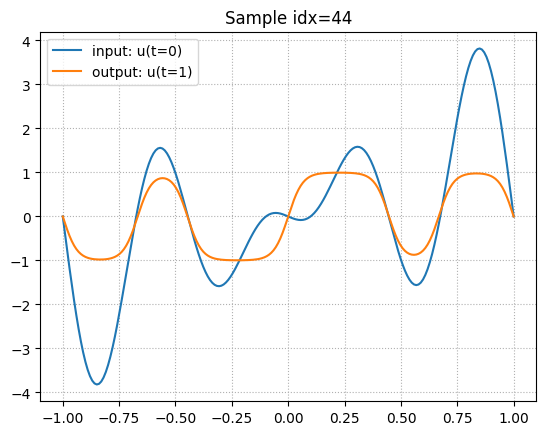

In [24]:
id_sample = np.random.randint(0, input_data_train.shape[0])
plt.figure()
plt.plot(input_data_train[id_sample, :, 0, 1], input_data_train[id_sample, :, 0, 0], label="input: u(t=0)")
plt.plot(np.linspace(-1, 1, output_data_train.shape[1]), output_data_train[id_sample, :], label="output: u(t=1)")
plt.grid(True, which="both", ls=":")
plt.title(f'Sample idx={id_sample}')
plt.legend()
plt.show()

In [26]:
def pde_residual_fft(u, x, t):

    alpha, beta = 0.0035, 0.7

    # Remove the right end of x-domain to avoid repeating the value (remember periodic BCs)
    u = u[:, :-1, :]
    x = x[:-1]
    X, _ = torch.meshgrid(x, t, indexing="ij")
    batchsize, nx, nt = u.shape

    # -------- FFT in space ----------
    u_hx = torch.fft.fft(u, dim=1)
    kx = torch.fft.fftfreq(nx, d=(x[1]-x[0])).to(u.device)
    kx = kx.reshape(1, nx, 1)
    u_xx_h = -(2*np.pi*kx)**2 * u_hx
    u_xx = torch.fft.ifft(u_xx_h, dim=1).real

    # -------- Finite differences in time ----------
    dt = t[1] - t[0]
    du_dt_center = (u[:, :, 2:] - u[:, :, :-2]) / (2*dt)

    # Forward/backward difference for boundaries
    du_dt_left  = (u[:, :, 1] - u[:, :, 0]) / dt
    du_dt_right = (u[:, :, -1] - u[:, :, -2]) / dt

    # Concatenate along time dimension
    u_t = torch.cat([
        du_dt_left.unsqueeze(2),
        du_dt_center,
        du_dt_right.unsqueeze(2)
    ], dim=2)

    # -------- Nonlinear term ----------
    u_nl = beta * u * (u**2 - 1)

    # -------- PDE residual ----------
    Du = u_t - alpha * u_xx + u_nl
    return Du


def bc_residual(u):
    # Periodic BCs u(x=0)=u(x=L) for all times
    return (u[:, 0, :] - u[:, -1, :]).flatten()


def ic_residual(u, u0):
    # Initial condition at t=0
    return (u - u0).flatten()


In [31]:
num_modes_x = 32
num_modes_t = 16
width = 64
n_layers = 4
fno = FNO2d(num_modes_x, num_modes_t, width, n_layers).to(device) # model

In [32]:
learning_rate = 1e-4
epochs = 500
step_size = 200
gamma = 0.5

optimizer = Adam(fno.parameters(), lr=learning_rate, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

In [33]:
test_loop = True

l = torch.nn.MSELoss()
loss_train = []
loss_train_pde = []
loss_train_bc = []
loss_train_ic = []
loss_train_data = []
loss_test = []
loss_test_pde = []
loss_test_bc = []
loss_test_ic = []
lambda_bc, lambda_ic, lambda_data = 1., 1., 1.
freq_print = 1
for epoch in range(epochs):
    train_loss, train_loss_pde, train_loss_bc, train_loss_ic, train_loss_data = 0.0, 0.0, 0.0, 0.0, 0.0
    for step, (input_batch, output_batch) in enumerate(training_set):
        optimizer.zero_grad()

        input_batch = input_batch.to(device)  # contains IC
        output_batch = output_batch.to(device)

        u_pred_train = fno(input_batch).squeeze(3)  # [batch, nx, nt]

        # Compute residuals
        pde_res = pde_residual_fft(u_pred_train, x, t)
        bc_res = bc_residual(u_pred_train)
        ic_res = ic_residual(u_pred_train[:, :, 0], input_batch[:, :, 0, 0])

        # Loss
        loss_pde = l(pde_res, torch.zeros_like(pde_res).to(device))
        loss_bc = l(bc_res, torch.zeros_like(bc_res).to(device))
        loss_ic = l(ic_res, torch.zeros_like(ic_res).to(device))
        #loss_data = l(u_pred_train[:, :, -1], output_batch)
        loss = loss_pde + lambda_bc*loss_bc + lambda_ic*loss_ic #+ lambda_data*loss_data

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loss_pde += loss_pde.item()
        train_loss_bc += loss_bc.item()
        train_loss_ic += loss_ic.item()
        #train_loss_data += loss_data.item()

    train_loss /= len(training_set)
    train_loss_pde /= len(training_set)
    train_loss_bc /= len(training_set)
    train_loss_ic /= len(training_set)
    #train_loss_data /= len(training_set)

    loss_train.append(train_loss)
    loss_train_pde.append(train_loss_pde)
    loss_train_bc.append(train_loss_bc)
    loss_train_ic.append(train_loss_ic)
    #loss_train_data.append(train_loss_data)

    scheduler.step()

    with torch.no_grad():
        fno.eval()
        test_relative_l2 = 0.0
        test_loss, test_loss_pde, test_loss_bc, test_loss_ic = 0.0, 0.0, 0.0, 0.0
        for step, (input_batch, output_batch) in enumerate(testing_set):
            input_batch = input_batch.to(device)
            output_batch = output_batch.to(device)

            # Forward pass
            u_pred_test = fno(input_batch).squeeze(3)

            # Residuals
            pde_res = pde_residual_fft(u_pred_test, x, t)
            bc_res = bc_residual(u_pred_test)
            ic_res = ic_residual(u_pred_test[:, :, 0], input_batch[:, :, 0, 0])

            # Loss
            loss_pde = l(pde_res, torch.zeros_like(pde_res).to(device))
            loss_bc = l(bc_res, torch.zeros_like(bc_res).to(device))
            loss_ic = l(ic_res, torch.zeros_like(ic_res).to(device))
            loss = loss_pde + lambda_bc*loss_bc + lambda_ic*loss_ic

            test_loss += loss.item()
            test_loss_pde += loss_pde.item()
            test_loss_bc += loss_bc.item()
            test_loss_ic += loss_ic.item()

            # Relative L2 error (%)
            final_time_output = u_pred_test[:, :, -1]
            loss_f = torch.sqrt(torch.mean((final_time_output - output_batch) ** 2) /
                                torch.mean(output_batch ** 2)) * 100
            test_relative_l2 += loss_f.item()

        test_relative_l2 /= len(testing_set)
        test_loss /= len(testing_set)
        test_loss_pde /= len(testing_set)
        test_loss_bc /= len(testing_set)
        test_loss_ic /= len(testing_set)

        loss_test.append(test_loss)
        loss_test_pde.append(test_loss_pde)
        loss_test_bc.append(test_loss_bc)
        loss_test_ic.append(test_loss_ic)

        fno.train()


    if epoch % freq_print == 0:
        print(f"######### Relative L2 Test Norm: {test_relative_l2:.5f}")
        print(f"######### Epoch: {epoch}, ######### Train Loss: {train_loss:.5f}, PDE: {train_loss_pde:.5f}, BC: {train_loss_bc:.5f}, IC: {train_loss_ic:.5f}")

######### Relative L2 Test Norm: 89.02718
######### Epoch: 0, ######### Train Loss: 2.56059, PDE: 0.00819, BC: 0.00005, IC: 2.55235
######### Relative L2 Test Norm: 76.03685
######### Epoch: 1, ######### Train Loss: 2.24629, PDE: 0.01313, BC: 0.00011, IC: 2.23306
######### Relative L2 Test Norm: 57.72033
######### Epoch: 2, ######### Train Loss: 1.82132, PDE: 0.03788, BC: 0.00056, IC: 1.78288
######### Relative L2 Test Norm: 41.67412
######### Epoch: 3, ######### Train Loss: 1.33844, PDE: 0.09846, BC: 0.00214, IC: 1.23783
######### Relative L2 Test Norm: 37.75970
######### Epoch: 4, ######### Train Loss: 1.05048, PDE: 0.22722, BC: 0.00324, IC: 0.82002
######### Relative L2 Test Norm: 36.39408
######### Epoch: 5, ######### Train Loss: 0.96664, PDE: 0.23555, BC: 0.00181, IC: 0.72928
######### Relative L2 Test Norm: 37.56498
######### Epoch: 6, ######### Train Loss: 0.91975, PDE: 0.13518, BC: 0.00033, IC: 0.78425
######### Relative L2 Test Norm: 39.49302
######### Epoch: 7, ######### Trai

KeyboardInterrupt: 

/tmp/ipython-input-1047387831.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipython-input-1047387831.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()
/tmp/ipython-input-1047387831.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


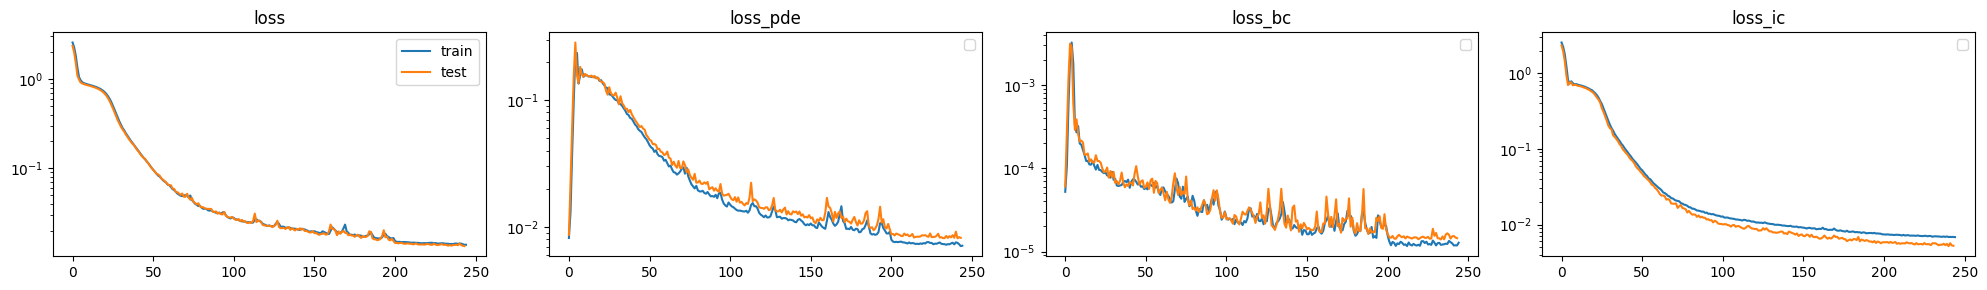

In [34]:
fig2, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 3))

ax1.semilogy(loss_train, label='train')
ax1.semilogy(loss_test, label='test')
ax1.set_title('loss')
ax1.legend()

ax2.semilogy(loss_train_pde)
ax2.semilogy(loss_test_pde)
ax2.set_title('loss_pde')
ax2.legend()

ax3.semilogy(loss_train_bc)
ax3.semilogy(loss_test_bc)
ax3.set_title('loss_bc')
ax3.legend()

ax4.semilogy(loss_train_ic)
ax4.semilogy(loss_test_ic)
ax4.set_title('loss_ic')
ax4.legend()

plt.tight_layout()
plt.show()

In [41]:
idx_data = np.random.randint(0, input_data_test.shape[0], 1).item()
print('idx_data: ', idx_data)

input_data_pred = torch.zeros((1, nx, nt, 3))
u0 = input_data_test[idx_data, :, 0, 0]

# broadcast IC along time
U0 = u0[:, None].repeat(1, nt)  # shape (nx, nt)

input_data_pred[0, :, :, 0] = U0
input_data_pred[0, :, :, 1] = X
input_data_pred[0, :, :, 2] = T

idx_data:  192


In [42]:
u_pred = fno(input_data_pred.to(device))
u_pred = u_pred.detach().cpu()[0, :, :, 0]  # shape [nx, nt]

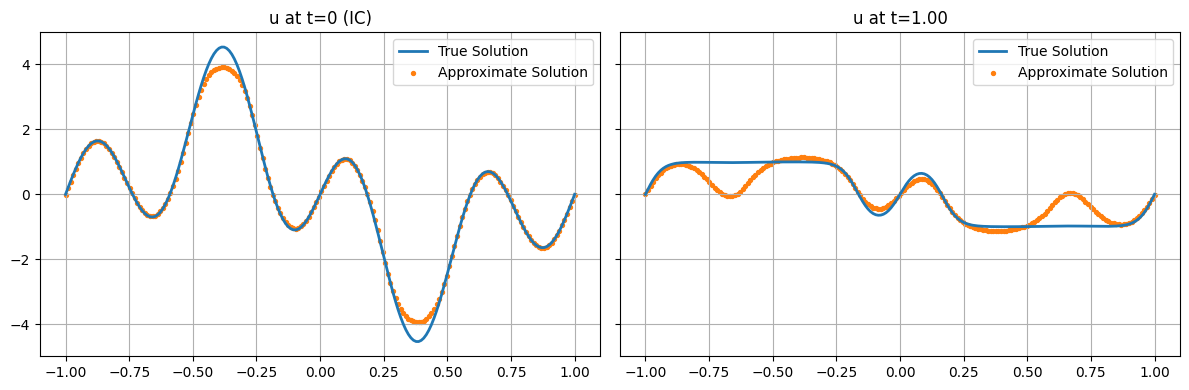

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# Initial condition (t=0)
ax1.plot(x.numpy(), u0, label="True Solution", color="C0", lw=2)
ax1.scatter(x.numpy(), u_pred[:, 0], label="Approximate Solution", color="C1", s=8)
ax1.set_title("u at t=0 (IC)")
ax1.grid(True)
ax1.legend()

# Final time step (t=nt-1)
u_true_final = output_data_test[idx_data, :]  # shape [nx]
ax2.plot(x.numpy(), u_true_final, label="True Solution", color="C0", lw=2)
ax2.scatter(x.numpy(), u_pred[:, -1], label="Approximate Solution", color="C1", s=8)
ax2.set_title(f"u at t={t[-1]:.2f}")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()